# Complete Equation for Gaussian Dispersion Modeling of Continuous, Buoyant Air Pollution Plumes

Goal: To compute $$C(x,y,z)=\frac{Q}{u}\cdot\frac{f}{\sigma_y\sqrt{2\pi}}\cdot\frac{g_1+g_2+g_3}{\sigma_z\sqrt{2\pi}},$$ where $C$ is the concentration of emissions in g/m$^3$ at any receptor located in position $(x,y,z)$. Source: https://en.wikipedia.org/wiki/Atmospheric_dispersion_modeling. In this equation, $x$ is the number of meters downwind from the emission source point, $y$ is the number of meters crosswind from the emission plume centerline, and $z$ is the number of meters above ground level.

## Fundamental Constants

These are constants that are reasonably well known and can be assumed.

In [1]:
g = 9.8 #acceleration due to gravity (m/s^2)
dTa_dz = -0.27965 #rate of temperature change with altitude (K/m) 
                #Source: https://scied.ucar.edu/learning-zone/atmosphere/change-atmosphere-altitude
Γ = 0.28295 #adiabatic lapse rate (K/m) Source:
        #https://forecast.weather.gov/glossary.php?word=lapse%20rate#:~:text=Adiabatic%20Lapse%20Rate,9.8%C2%B0C%20per%20kilometer

## Given values (Inputs)

These are going to be the values that must be input to determine the concentration. I am hoping these are known from whatever model we are using (need to ask about this). 

In [2]:
#reasonable values for all input quantities based on sources (can be changed once given actual data)
Q = (18887395*5.399*1000)/(3.154e7) #source pollutant emission rate (g/s)
                                    #value is emission rate for John E Adams plant in 2005 (converted to g/s); Source:
                                #http://www.cec.org/files/documents/publications/10236-north-american-power-plant-air-emissions-en.pdf

def u_func(t):
    u = t + 0.01
    return u

# u = 3.5 #horizontal wind velocity along the plume centerline (m/s)
        #value based on average wind speed data at 30m (value claims < 4.0 so just guessing here)
        #Source: https://windexchange.energy.gov/maps-data/325
daytime = True #if False: nighttime
Hs = 91.44 #height of stack (m)
          #value is average stack height
          #Source: https://www.tandfonline.com/doi/pdf/10.1080/00022470.1963.10468165
w0 = 9.92 #initial plume vertical speed (m/s) [usually taken as stack exit velocity]
          #mean exit gas velocity as reported by the EPA in 1999
          #Source: https://www.epa.gov/sites/default/files/2014-03/documents/stacks99.pdf
D = 10 #internal stack diameter (m)
       #average diameter of industrial smoke stack
       #Source: https://www.nist.gov/news-events/news/2014/08/scale-model-smokestack-study-ghg-emissions-monitoring
Ts = 463.15 #stack gas temperature (K)
            #average value stated in EPA Stack Gas Reheat Evaluation in 1980 (converted from F to K)
            #Source: https://nepis.epa.gov/Exe/ZyNET.exe/...
Ta = 288.15 + (dTa_dz*Hs) #air temperature (K)
                          #average air temperature at sea level (converted from C to K) with change in temp at stack altitude added
                          #Source: https://www.flyingmag.com/guides/what-is-standard-temperature-aviation/
L = 240 #height from ground level to bottom of ht einversion aloft (m) 
        #value is average in Allegheny County, Pennsylvania over a 10 year period; Source:
        #https://www.alleghenycounty.us/files/assets/county/v/1/government/health/documents/air-quality/sadar-emplus-article-reprint.pdf

3233.133976062143


## Location of desired concentration of emissions relative to the emission source
Dependent variables

In [3]:
#User input
x = 1000 #number of meters downwind from emission source point we are interested in calculating concentration at
y = 0 #number of meters crosswind from the emission plume centerline we are interested in calculating concentration at
z = Hs #number of meters above ground level we are interested in calculating concentration at
t = 1 #time (arbitrary for now)

## Computing the standard deviations of the emission distribution, $\sigma_y$ and $\sigma_z$

We now aim to calculate the horizontal and vertical standard deviations of the emission distrubution, $\sigma_y$ and $\sigma_z$, in m. The equations for these are given by:
$$\sigma_y=\exp(I_y+J_y\ln(x)+K_y[\ln(x)]^2),\quad \quad\sigma_z=\exp(I_z+J_z\ln(x)+K_z[\ln(x)]^2).$$
Note here that the coefficients, $I_y$, $I_z$, $J_y$, $J_z$, $K_y$, and $K_z$ are given by the values in the following table based on stability class:

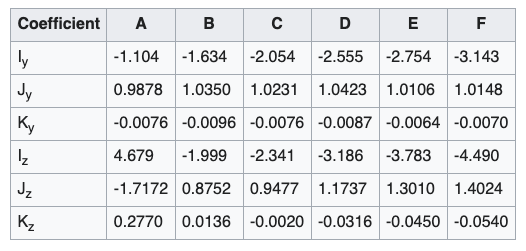

The classification of stability class is proposed by F. Pasquill. The six stability classes are referred to: A-extremely unstable B-moderately unstable C-slightly unstable D-neutral E-slightly stable F-moderately stable. One can determine the stability class based on surface wind speed and sky conditions using the following table. Source: https://dc.uwm.edu/cgi/viewcontent.cgi?article=2458&context=etd.

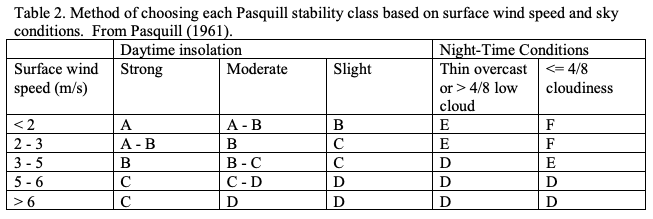

In [4]:
#determine values of coefficients Iy, Jy, Ky, Iz, Jz, and Kz

u = u_func(t)

if u < 2:
    if daytime == True:
        #taking average between A and B values
        Iy = (-1.104 + -1.634) / 2
        Jy = (0.9878 + 1.0350) / 2
        Ky = (-0.0076 + -0.0096) / 2
        Iz = (4.679 + -1.999) / 2
        Jz = (-1.7172 + 0.8752) / 2
        Kz = (0.2770 + 0.0136) / 2
        stabEF = False
    else:
        #taking average between E and F values
        Iy = (-2.754 + -3.143) / 2
        Jy = (1.0106 + 1.0148) / 2
        Ky = (-0.0064 + -0.0070) / 2
        Iz = (-3.783 + -4.490) / 2
        Jz = (1.3010 + 1.4024) / 2
        Kz = (-0.0450 + -0.0540) /2
        stabEF = True
elif (u >= 2) and (u < 3):
    if daytime == True:
        #taking "weighted average" over A, B, and C values
        Iy = ((0.5*(-1.104)) + (1.5*(-1.634)) + -2.0554) / 3
        Jy = ((0.5*0.9878) + (1.5*1.0350) + 1.0231) / 3
        Ky = ((0.5*(-0.0076)) + (1.5*(-0.0096)) + -0.0076) / 3
        Iz = ((0.5*4.679) + (1.5*(-1.999)) + -2.341) / 3
        Jz = ((0.5*(-1.7172)) + (1.5*0.8752) + 0.9477) / 3
        Kz = ((0.5*0.2770) + (1.5*0.0136) + -0.0020) / 3
        stabEF = False
    else:
        #taking average between E and F values
        Iy = (-2.754 + -3.143) / 2
        Jy = (1.0106 + 1.0148) / 2
        Ky = (-0.0064 + -0.0070) / 2
        Iz = (-3.783 + -4.490) / 2
        Jz = (1.3010 + 1.4024) / 2
        Kz = (-0.0450 + -0.0540) /2 
        stabEF = True
elif (u >= 3) and (u < 5):
    if daytime == True:
        #taking average between B and C values
        Iy = (-1.634 + -2.054) / 2
        Jy = (1.0350 + 1.0231) / 2
        Ky = (-0.0096 + -0.0076) / 2
        Iz = (-1.999 + -2.341) / 2
        Jz = (0.8752 + 0.9477) / 2
        Kz = (0.0136 + -0.0020) / 2
        stabEF = False
    else:
        #taking average between D and E values
        Iy = (-2.555 + -2.754) / 2
        Jy = (1.0423 + 1.0106) / 2
        Ky = (-0.0087 + -0.0064) / 2
        Iz = (-3.186 + -3.783) / 2
        Jz = (1.1737 + 1.3010) / 2
        Kz = (-0.0316 + -0.0450) / 2
        stabEF = True #could technically also be False; making a choice here
elif (u >= 5) and (u <= 6):
    if daytime == True:
        #taking average between C and D values
        Iy = (-2.054 + -2.555) / 2
        Jy = (1.0231 + 1.0423) / 2
        Ky = (-0.0076 + -0.0087) / 2
        Iz = (-2.341 + -3.186) / 2
        Jz = (0.9477 + 1.1737) / 2
        Kz = (-0.0020 + -0.0316) / 2
        stabEF = False
    else:
        #taking D values
        Iy = -2.555
        Jy = 1.0423
        Ky = -0.0087
        Iz = -3.186
        Jz = 1.1737
        Kz = -0.0316
        stabEF = False        
else:
    if daytime == True:
        #taking "weighted average" of C and D values
        Iy = (-2.054 + (2*(-2.555))) / 3
        Jy = (1.0231 + (2*1.0423)) / 3
        Ky = (-0.0076 + (2*(-0.0087))) / 3
        Iz = (-2.341 + (2*(-3.186))) / 3
        Jz = (0.9477 + (2*1.1737)) / 3
        Kz = (-0.0020 + (2*(-0.0316))) / 3
        stabEF = False        
    else: 
        #taking D values
        Iy = -2.555
        Jy = 1.0423
        Ky = -0.0087
        Iz = -3.186
        Jz = 1.1737
        Kz = -0.0316
        stabEF = False 

In [5]:
import math
σy = math.exp(Iy+(Jy*math.log(x))+(Ky*((math.log(x))**2)))
σz = math.exp(Iz+(Jz*math.log(x))+(Kz*((math.log(x))**2)))
print(σy,σz)

182.57056857609626 213.81842779496802


## Computing crosswind dispersion parameter $f$

The crosswind dispersion parameter is computed via: 
$$f=\exp\left(\frac{-y^2}{2\sigma_y^2}\right).$$

In [6]:
f = math.exp((-y**2)/(2*(σy**2)))
print(f)

1.0


## Computing the height of emission plume centerline above ground level, $H$

$H$ is the height of emission plume centerline above ground level in meters. It is made up of the actual stack height, $Hs$, and the plume rise, $\Delta h$. As such, we can compute $H$ via:
$$H = Hs + \Delta h.$$

While we are assuming that $Hs$ is given, determining $\Delta h$ requires some further thought and computation. We can use Briggs plume rise equations to determine $\Delta h$. A logic diagram for using the Briggs equations to obtain the plume rise trajectory of bent-over buoyant plumes is presented below:

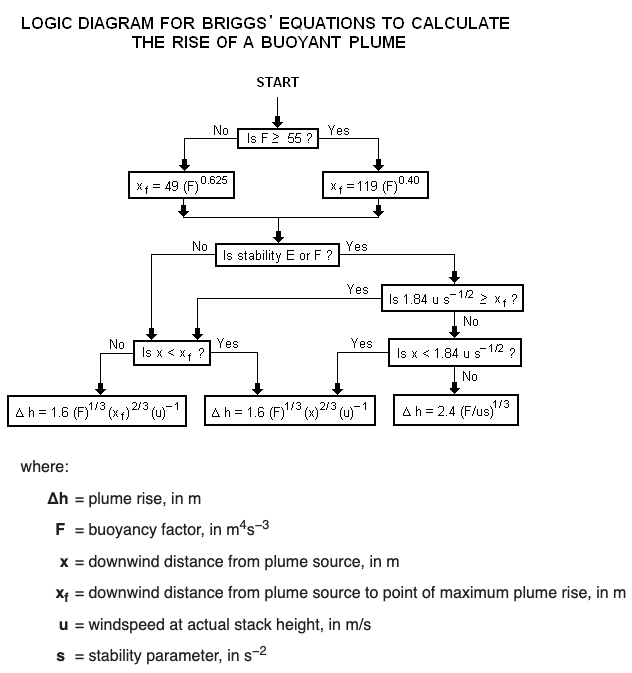

We see that the logic diagram depends on the buoyancy factor, $F$. This is given by:
$$F=w_0g\left(\frac{D}{2}\right)^2\left(\frac{T_s}{T_a}-1\right),$$
where $w_0$ is the initial plume vertical speed (m/s), $g$ is the acceleration due to gravity (m/s$^2$), $D$ is the internal stack diameter (m), $T_s$ is the stack gas temperature (K), and $T_a$ is the air temperature (K). Note that $w_0$ is usally taken as the stack exit velocity. We are going to take each of these quantities as given. Source: https://www.euromotor.org/mod/resource/view.php?id=14613&forceview=1. Note that there was a typo in the formula on the source website, but the typo is fixed here.

In [7]:
F = w0*g*((D/2)**2)*((Ts/Ta)-1)
print(F)

1019.2550302404087


The logic diagram also depends on the stability paramter, $s$. This is given by: 
$$s=\left(\frac{g}{T_a}\right)\left[\left(\frac{\mathrm{d}T_a}{\mathrm{d}z}\right)+\Gamma\right],$$
where $\frac{\mathrm{d}T_a}{\mathrm{d}z}$ is the rate of temperature change with altitude and $\Gamma$ is the adiabatic lapse rate. Source: https://www.euromotor.org/mod/resource/view.php?id=14613&forceview=1. 

In [8]:
s = (g/Ta)*(dTa_dz + Γ)
print(s)

0.33376601481368967


We now use the calculated buoyancy factor and stability parameter along with the given velocity, $u$, and $x$-value to determine $\Delta h$ using the above logic diagram.

In [9]:
#determine xf value
if F >= 55:
    xf = 119*(F**0.40)
else: 
    xf = 49*(F**0.625)

#continue down logic diagram
if stabEF == True:
    if (1.84*u*(s**(-0.5))) >= xf:
        if x < xf:
            dh = 1.6*(F**(1/3))*(x**(2/3))*(u**(-1))
        else:
            dh = 1.6*(F**(1/3))*(xf**(2/3))*(u**(-1))
    else:
        if x < (1.84*u*(s**(-0.5))):
            dh = 1.6*(F**(1/3))*(x**(2/3))*(u**(-1))
        else:
            dh = 2.4*((F/(u*s))**(1/3))
else:
    if x < xf:
        dh = 1.6*(F**(1/3))*(x**(2/3))*(u**(-1))
    else:
        dh = 1.6*(F**(1/3))*(xf**(2/3))*(u**(-1))

In [10]:
print(dh)

1594.2615182215811


Now that we have $\Delta h$, we can compute $H=H_s+\Delta h$.

In [11]:
H = Hs + dh
print(H)

1685.7015182215812


## Computing vertical dispersion parameter, $g_1+g_2+g_3$

We begin with the vertical dispersion parameter with no reflections, $g1$, given by:
$$g_1=\exp\left[\frac{-(z-H)^2}{2\sigma_z^2}\right].$$

In [12]:
g1 = math.exp((-((z-H)**2))/(2*(σz**2)))
print((-((z-H)**2))/(2*(σz**2)))
print(g1)

-27.797060181614032
8.470131443939663e-13


We now compute the vertical dispersion for reflection from the ground, $g_2$, given by:
$$g_2=\exp\left[\frac{-(z+H)^2}{2\sigma_z^2}\right].$$

In [13]:
g2 = math.exp((-((z+H)**2))/(2*(σz**2)))
print(g2)

9.986632679211538e-16


Finally, we compute the vertical dispersion for reflection from an inversion aloft, $g_3$. Note that should we choose not to include the inversion aloft in the model, that this term will be omitted from the calculation of the concentration of emissions. The equation for $g_3$ is given by:
$$g_3=\sum_{m=1}^\infty\left\{\exp\left[\frac{-(z-H-2mL)^2}{2\sigma_z^2}\right]+\exp\left[\frac{-(z+H+2mL)^2}{2\sigma_z^2}\right]+\exp\left[\frac{-(z+H-2mL)^2}{2\sigma_z^2}\right]+\exp\left[\frac{-(z-H+2mL)^2}{2\sigma_z^2}\right]\right\}.$$
We note that according to the source with the model, truncating the sum to three terms generally gives an adequate solution, so that is what we do here.

In [14]:
g3 = 0.0
for m in range(1,3+1):
    term1 = math.exp((-((z-H-(2*m*L))**2))/(2*(σz**2))) + math.exp((-((z+H+(2*m*L))**2))/(2*(σz**2)))
    term2 = math.exp((-((z+H-(2*m*L))**2))/(2*(σz**2))) + math.exp((-((z-H+(2*m*L))**2))/(2*(σz**2)))
    g3 += term1 + term2
print(g3)

1.0723038908945364


## Computing concentration of emissions

As a reminder, the model for computing the concentration of emssions, $C$, at a point in space $(x,y,z)$ is:
$$C(x,y,z) = \frac{Q}{u}\cdot\frac{f}{\sigma_y\sqrt{2\pi}}\cdot\frac{g_1+g_2+g_3}{\sigma_z\sqrt{2\pi}}.$$

In [15]:
C = (Q/u)*(f/(σy*math.sqrt(2*math.pi)))*((g1+g2+g3)/(σz*math.sqrt(2*math.pi)))
print(C)

0.013994727331669954


# Making everything into functions

In [16]:
def σ(u,daytime,x):
    #determine values of coefficients Iy, Jy, Ky, Iz, Jz, and Kz
    if u < 2:
        if daytime == True:
            #taking average between A and B values
            Iy = (-1.104 + -1.634) / 2
            Jy = (0.9878 + 1.0350) / 2
            Ky = (-0.0076 + -0.0096) / 2
            Iz = (4.679 + -1.999) / 2
            Jz = (-1.7172 + 0.8752) / 2
            Kz = (0.2770 + 0.0136) / 2
            stabEF = False
        else:
            #taking average between E and F values
            Iy = (-2.754 + -3.143) / 2
            Jy = (1.0106 + 1.0148) / 2
            Ky = (-0.0064 + -0.0070) / 2
            Iz = (-3.783 + -4.490) / 2
            Jz = (1.3010 + 1.4024) / 2
            Kz = (-0.0450 + -0.0540) /2
            stabEF = True
    elif (u >= 2) and (u < 3):
        if daytime == True:
            #taking "weighted average" over A, B, and C values
            Iy = ((0.5*(-1.104)) + (1.5*(-1.634)) + -2.0554) / 3
            Jy = ((0.5*0.9878) + (1.5*1.0350) + 1.0231) / 3
            Ky = ((0.5*(-0.0076)) + (1.5*(-0.0096)) + -0.0076) / 3
            Iz = ((0.5*4.679) + (1.5*(-1.999)) + -2.341) / 3
            Jz = ((0.5*(-1.7172)) + (1.5*0.8752) + 0.9477) / 3
            Kz = ((0.5*0.2770) + (1.5*0.0136) + -0.0020) / 3
            stabEF = False
        else:
            #taking average between E and F values
            Iy = (-2.754 + -3.143) / 2
            Jy = (1.0106 + 1.0148) / 2
            Ky = (-0.0064 + -0.0070) / 2
            Iz = (-3.783 + -4.490) / 2
            Jz = (1.3010 + 1.4024) / 2
            Kz = (-0.0450 + -0.0540) /2 
            stabEF = True
    elif (u >= 3) and (u < 5):
        if daytime == True:
            #taking average between B and C values
            Iy = (-1.634 + -2.054) / 2
            Jy = (1.0350 + 1.0231) / 2
            Ky = (-0.0096 + -0.0076) / 2
            Iz = (-1.999 + -2.341) / 2
            Jz = (0.8752 + 0.9477) / 2
            Kz = (0.0136 + -0.0020) / 2
            stabEF = False
        else:
            #taking average between D and E values
            Iy = (-2.555 + -2.754) / 2
            Jy = (1.0423 + 1.0106) / 2
            Ky = (-0.0087 + -0.0064) / 2
            Iz = (-3.186 + -3.783) / 2
            Jz = (1.1737 + 1.3010) / 2
            Kz = (-0.0316 + -0.0450) / 2
            stabEF = True #could technically also be False; making a choice here
    elif (u >= 5) and (u <= 6):
        if daytime == True:
            #taking average between C and D values
            Iy = (-2.054 + -2.555) / 2
            Jy = (1.0231 + 1.0423) / 2
            Ky = (-0.0076 + -0.0087) / 2
            Iz = (-2.341 + -3.186) / 2
            Jz = (0.9477 + 1.1737) / 2
            Kz = (-0.0020 + -0.0316) / 2
            stabEF = False
        else:
            #taking D values
            Iy = -2.555
            Jy = 1.0423
            Ky = -0.0087
            Iz = -3.186
            Jz = 1.1737
            Kz = -0.0316
            stabEF = False        
    else:
        if daytime == True:
            #taking "weighted average" of C and D values
            Iy = (-2.054 + (2*(-2.555))) / 3
            Jy = (1.0231 + (2*1.0423)) / 3
            Ky = (-0.0076 + (2*(-0.0087))) / 3
            Iz = (-2.341 + (2*(-3.186))) / 3
            Jz = (0.9477 + (2*1.1737)) / 3
            Kz = (-0.0020 + (2*(-0.0316))) / 3
            stabEF = False        
        else: 
            #taking D values
            Iy = -2.555
            Jy = 1.0423
            Ky = -0.0087
            Iz = -3.186
            Jz = 1.1737
            Kz = -0.0316
            stabEF = False 

    σy = math.exp(Iy+(Jy*math.log(x))+(Ky*((math.log(x))**2)))
    σz = math.exp(Iz+(Jz*math.log(x))+(Kz*((math.log(x))**2)))

    return σy,σz,stabEF

In [17]:
def deltaH(F,stabEF,u,s,x):
    #determine xf value
    if F >= 55:
        xf = 119*(F**0.40)
    else: 
        xf = 49*(F**0.625)
    
    #continue down logic diagram
    if stabEF == True:
        if (1.84*u*(s**(-0.5))) >= xf:
            if x < xf:
                dh = 1.6*(F**(1/3))*(x**(2/3))*(u**(-1))
            else:
                dh = 1.6*(F**(1/3))*(xf**(2/3))*(u**(-1))
        else:
            if x < (1.84*u*(s**(-0.5))):
                dh = 1.6*(F**(1/3))*(x**(2/3))*(u**(-1))
            else:
                dh = 2.4*((F/(u*s))**(1/3))
    else:
        if x < xf:
            dh = 1.6*(F**(1/3))*(x**(2/3))*(u**(-1))
        else:
            dh = 1.6*(F**(1/3))*(xf**(2/3))*(u**(-1))

    return dh

In [18]:
def g3Val(z,H,L,σz):
    g3 = 0.0
    for m in range(1,3+1):
        term1 = math.exp((-((z-H-(2*m*L))**2))/(2*(σz**2))) + math.exp((-((z+H+(2*m*L))**2))/(2*(σz**2)))
        term2 = math.exp((-((z+H-(2*m*L))**2))/(2*(σz**2))) + math.exp((-((z-H+(2*m*L))**2))/(2*(σz**2)))
        g3 += term1 + term2
    return g3

In [19]:
def Concentration(x,y,z,t):
    u = u_func(t)
    σy,σz,stabEF = σ(u,daytime,x)
    f = math.exp((-y**2)/(2*(σy**2)))
    F = w0*g*((D/2)**2)*((Ts/Ta)-1)
    s = (g/Ta)*(dTa_dz + Γ)
    dh = deltaH(F,stabEF,u,s,x)
    H = Hs + dh
    g1 = math.exp((-((z-H)**2))/(2*(σz**2)))
    g2 = math.exp((-((z+H)**2))/(2*(σz**2)))
    g3 = g3Val(z,H,L,σz)
    C = (Q/u)*(f/(σy*math.sqrt(2*math.pi)))*((g1+g2+g3)/(σz*math.sqrt(2*math.pi)))
    return C

In [20]:
print(Concentration(100000000,0,10,1))

9.949209443241033e-22


In [21]:
import numpy as np
def Concentration_time(x,y,z,t):
    C = np.zeros((101,101))
    z = 10 #choosing an arbitrary fixed height of 10m
    i = 0
    for x in range(0,1010000,10000):
        if x == 0:
            x = 0.1
        j = 0
        for y in range(-500000,510000,10000):
            C[i,j] = Concentration(x,y,z,t)
            j += 1
        i += 1
    return C

In [28]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

In [29]:
# Example data
xvals = np.linspace(0,1000000,101)
yvals = np.linspace(-500000,510000,101)
X, Y = np.meshgrid(xvals, yvals)
# Use a logarithmic normalization for the color scale
norm = plt.Normalize(vmin=0, vmax=10)

In [30]:
C = Concentration_time(x,y,z,0)

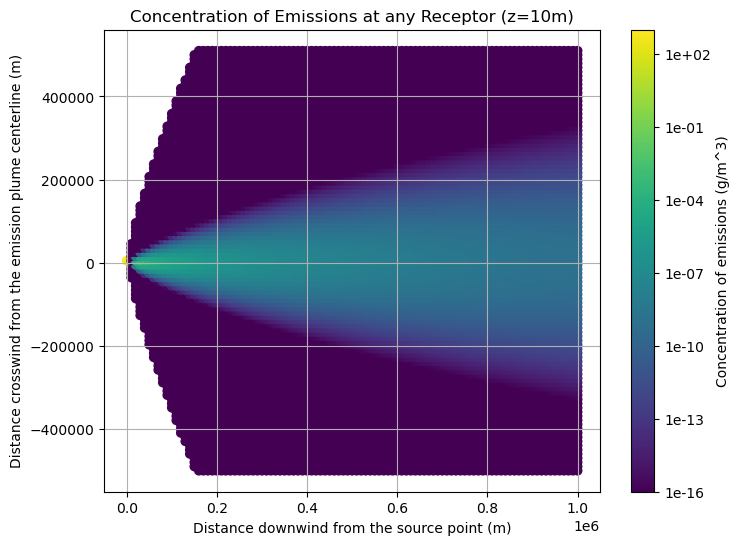

In [31]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X, Y, c=C.transpose(), cmap='viridis',norm=LogNorm(vmin=1e-16,vmax=1000))
plt.colorbar(label='Concentration of emissions (g/m^3)',format='%.0e')  # Add color bar with label
plt.title('Concentration of Emissions at any Receptor (z=10m)')
plt.xlabel('Distance downwind from the source point (m)')
plt.ylabel('Distance crosswind from the emission plume centerline (m)')
plt.grid(True)  # Show grid
plt.show()

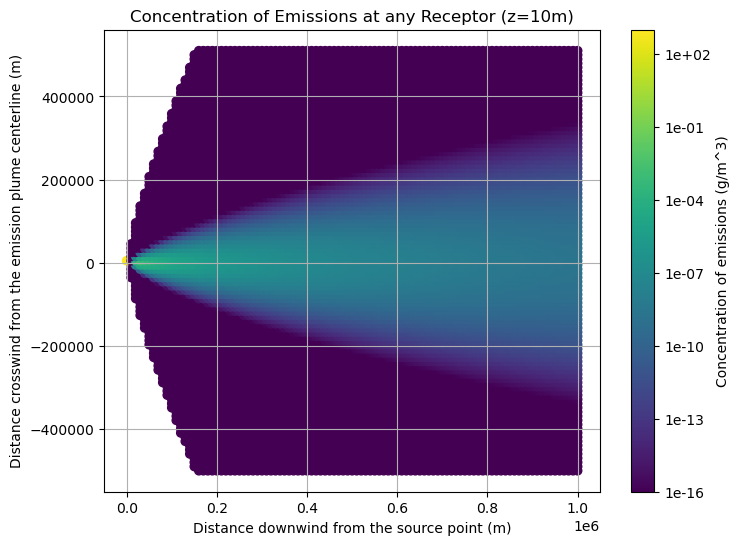

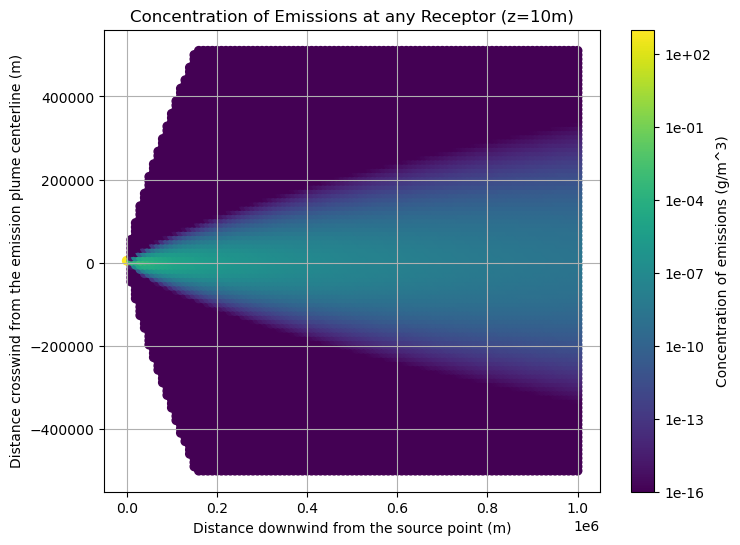

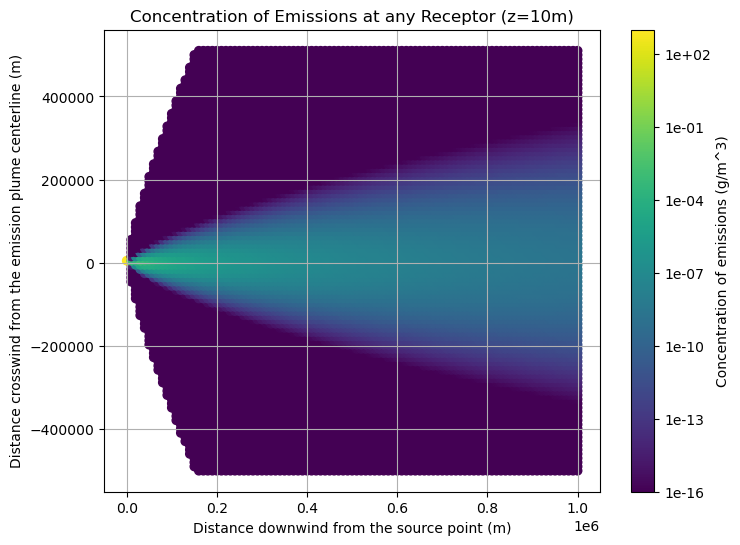

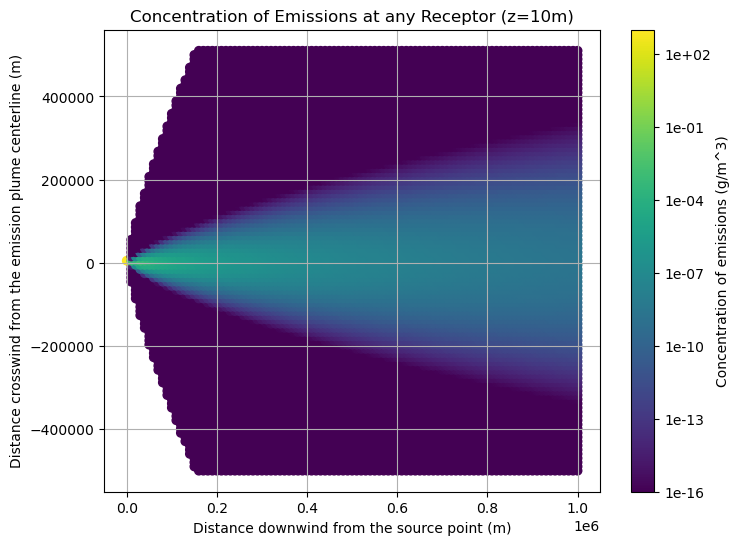

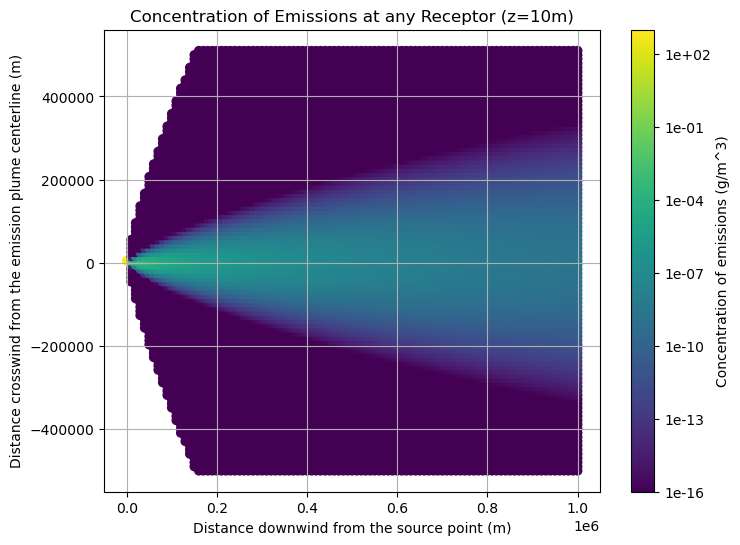

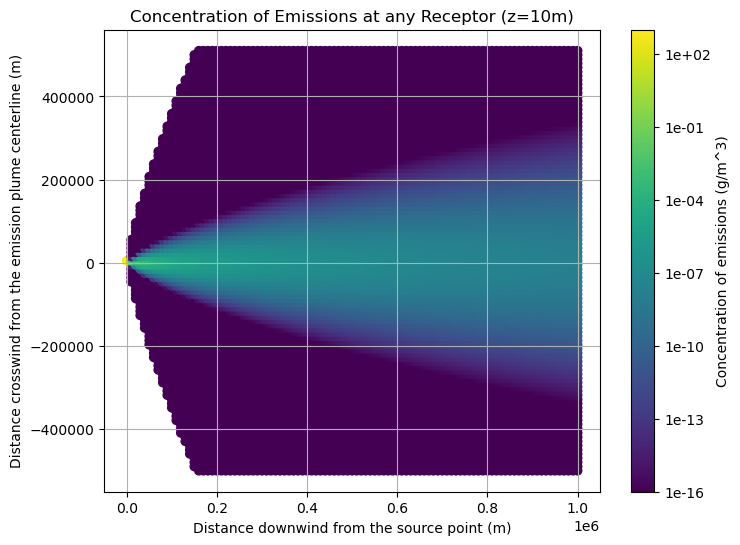

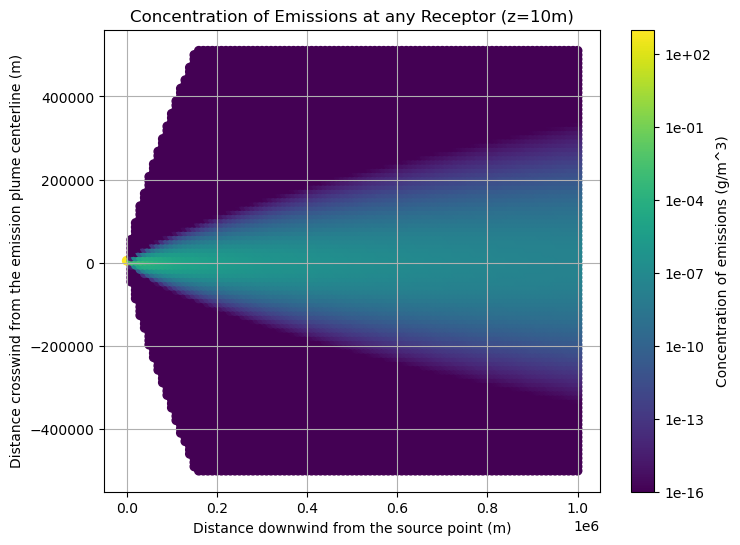

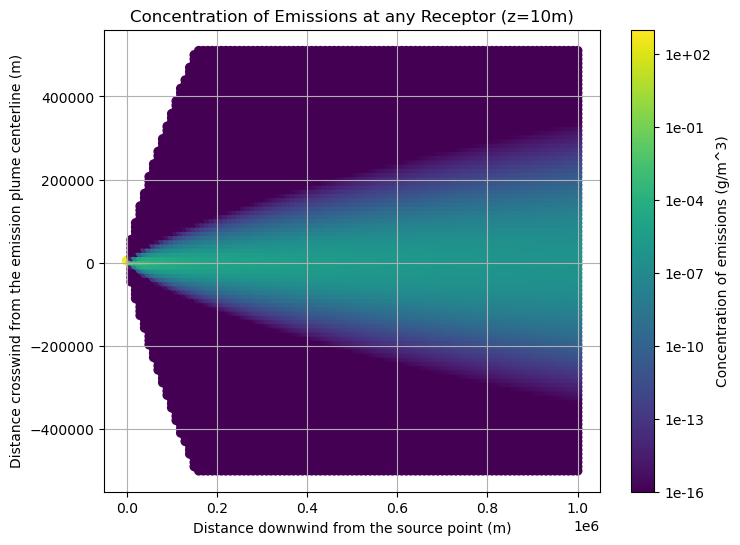

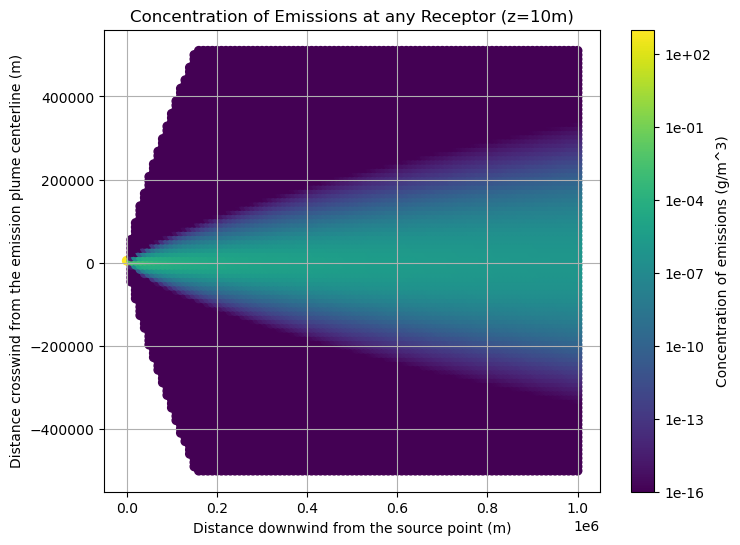

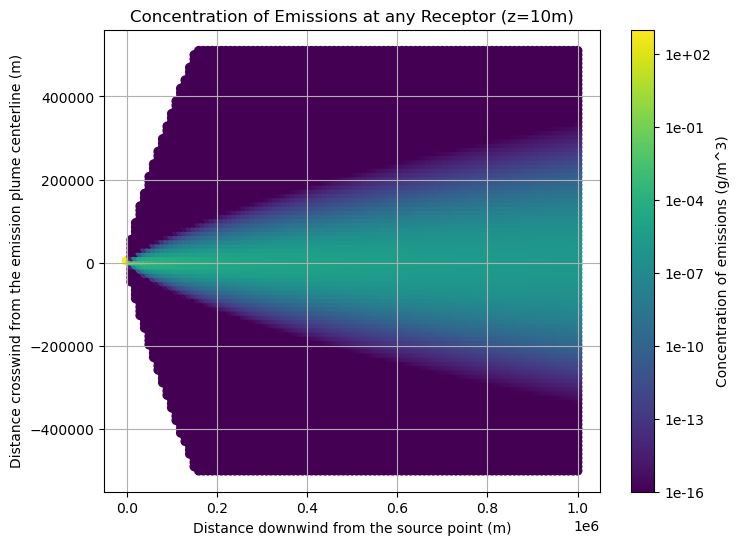

In [32]:
t_vals = np.linspace(0,4,10)
for t in t_vals:
    # C = Concentration_time(x,y,z,t)  # Modify C for animation
    C = C + Concentration_time(x,y,z,t)
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(X, Y, c=C.transpose(), cmap='viridis',norm=LogNorm(vmin=1e-16,vmax=1000))
    plt.colorbar(label='Concentration of emissions (g/m^3)',format='%.0e')  # Add color bar with label
    plt.title('Concentration of Emissions at any Receptor (z=10m)')
    plt.xlabel('Distance downwind from the source point (m)')
    plt.ylabel('Distance crosswind from the emission plume centerline (m)')
    plt.grid(True)  # Show grid
    plt.savefig("test"+str(t)+".png")
plt.show()